In [43]:
!pip install pandas scikit-learn requests matplotlib

In [44]:
# Inisialisasi Library

import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [45]:
# Mengambil Data Mentah dari Firebase

url = "https://suhu-kelembapan-bpvp-sda-default-rtdb.firebaseio.com/sensor/dht.json"

response = requests.get(url)
raw_data = response.json()

print("Data mentah dari Firebase:")
print(raw_data)

Data mentah dari Firebase:
{'-Os-kF0WM7hnHXY_P6Cq': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kH2XRlYrANAQVIz3': {'kelembaban': 40.0, 'suhu': 23.9}, '-Os-kJEU4BqxkEh_YROH': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kLXHMOcwo6RRZRPL': {'kelembaban': 40.0, 'suhu': 24.2}, '-Os-kNl5rK_d4Llqbtg4': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-kPvZEOAahOjZADwQ': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kRunGZq6jZjkI7Ly': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kU8c7zW7OO2nAa7R': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-kWI5pJ4ivHNQjM4Y': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-kYWwgDPAksukIP8s': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-klRtcXzZoVtFQ7Lw': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-mcVhFX1mLlAiw-Da': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-mfE9Mqt_RtJoVdTv': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-mhxaue6KsdaAFtwc': {'kelembaban': 40.0, 'suhu': 24.2}, '-Os-mkktkyfTopEXwTY_': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-mnVMUu3_Uk-XLKAa': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os3OxJEoqA

In [46]:
# Membuat Format Dataframe

clean_rows = []

for key, value in raw_data.items():
    if isinstance(value, dict) and "dht" in value:
        sensor_data = value['dht']
        clean_rows.append(sensor_data)

df = pd.DataFrame(clean_rows)

print("DataFrame bersih:")
print(df.head())

print("Kolom:")
print(df.columns)

DataFrame bersih:
Empty DataFrame
Columns: []
Index: []
Kolom:
RangeIndex(start=0, stop=0, step=1)


In [47]:
# Isi Dataframe

print("Isi data")
print(raw_data)

print("\nTipe data:", type(raw_data))

Isi data
{'-Os-kF0WM7hnHXY_P6Cq': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kH2XRlYrANAQVIz3': {'kelembaban': 40.0, 'suhu': 23.9}, '-Os-kJEU4BqxkEh_YROH': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kLXHMOcwo6RRZRPL': {'kelembaban': 40.0, 'suhu': 24.2}, '-Os-kNl5rK_d4Llqbtg4': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-kPvZEOAahOjZADwQ': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kRunGZq6jZjkI7Ly': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os-kU8c7zW7OO2nAa7R': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-kWI5pJ4ivHNQjM4Y': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-kYWwgDPAksukIP8s': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-klRtcXzZoVtFQ7Lw': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-mcVhFX1mLlAiw-Da': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-mfE9Mqt_RtJoVdTv': {'kelembaban': 40.0, 'suhu': 24.1}, '-Os-mhxaue6KsdaAFtwc': {'kelembaban': 40.0, 'suhu': 24.2}, '-Os-mkktkyfTopEXwTY_': {'kelembaban': 40.0, 'suhu': 24.0}, '-Os-mnVMUu3_Uk-XLKAa': {'kelembaban': 40.0, 'suhu': 23.8}, '-Os3OxJEoqAvs3UnvSiV': {'kele

In [48]:
sensor_data = raw_data.get("dht", {})

# Ubah data langsung ke DataFrame
df = pd.DataFrame.from_dict(raw_data, orient='index')

print("DataFrame awal:")
print(df.head())

DataFrame awal:
                      kelembaban  suhu
-Os-kF0WM7hnHXY_P6Cq        40.0  23.8
-Os-kH2XRlYrANAQVIz3        40.0  23.9
-Os-kJEU4BqxkEh_YROH        40.0  23.8
-Os-kLXHMOcwo6RRZRPL        40.0  24.2
-Os-kNl5rK_d4Llqbtg4        40.0  24.0


In [49]:
# Jumlah Data pada Database
print(len(df))

621


In [50]:
# Pemodelan Regresi Linear

from sklearn.linear_model import LinearRegression
import numpy as np

# x - variabel bebas (kelembaban)
x = df[['kelembaban']]

# y - variabel target (suhu)
y = df[['suhu']]

print("Ukuran X:", x.shape)
print("Ukuran Y:", y.shape)

Ukuran X: (621, 1)
Ukuran Y: (621, 1)


In [51]:
# Identifikasi Koefisien dan Prediksi Suhu Regresi Linear

model = LinearRegression()
model.fit(x, y)
df["Prediksi_Suhu"] = model.predict(x)

print("Koefisien (slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("Prediksi Suhu:", model.predict(x))

Koefisien (slope): [0.26634668]
Intercept: [8.31900987]
Prediksi Suhu: [[18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [18.97287727]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [29.36039798]
 [30.82530475]
 [28.69453127]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [30.29261138]
 [18.97287727]
 [28.69453127]
 [28.69453127]
 [28.69453127]
 [28.69453127]
 [28.69453127]
 [28.69453127]
 [28.69453127]
 [28.69453127]
 [28.69453127]

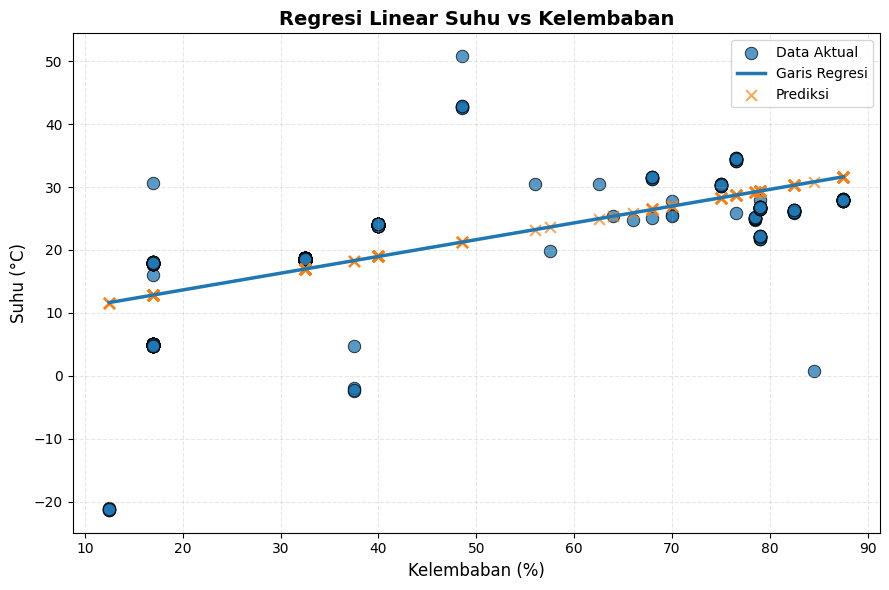

In [56]:
# Visualisasi Regresi Linear

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

# Scatter plot (BEST STYLE)
plt.scatter(
        df["kelembaban"],
        df["suhu"],
        marker='o',           # clean & umum
        s=80,                 # ukuran pas
        alpha=0.75,           # transparansi
        edgecolors='black',   # outline biar jelas
        linewidths=0.7,
        label='Data Aktual'
    )

# Urutkan data agar garis halus
sorted_df = df.sort_values(by="kelembaban")

# Garis regresi
m, c = np.polyfit(sorted_df["kelembaban"], sorted_df["suhu"], 1)
plt.plot(
        sorted_df["kelembaban"],
        m * sorted_df["kelembaban"] + c,
        linestyle='-',
        linewidth=2.5,
        label='Garis Regresi'
    )

# Highlight titik prediksi
plt.scatter(
        df["kelembaban"],
        df["Prediksi_Suhu"],
        marker='x',
        s=60,
        alpha=0.7,
        label='Prediksi'
    )

# Styling biar clean
plt.title("Regresi Linear Suhu vs Kelembaban", fontsize=14, fontweight='bold')
plt.xlabel("Kelembaban (%)", fontsize=12)
plt.ylabel("Suhu (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# Pemodelan Regresi Polinomial

from sklearn.preprocessing import PolynomialFeatures
import numpy as np

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

df["Prediksi_Poly"] = model_poly.predict(X_poly)

print("Prediksi Poly:", model_poly.predict(X_poly))

Prediksi Poly: [[23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [23.23198001]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [28.05974804]
 [26.53500578]
 [28.57258134]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [27.15253849]
 [23.23198001]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258134]
 [28.57258

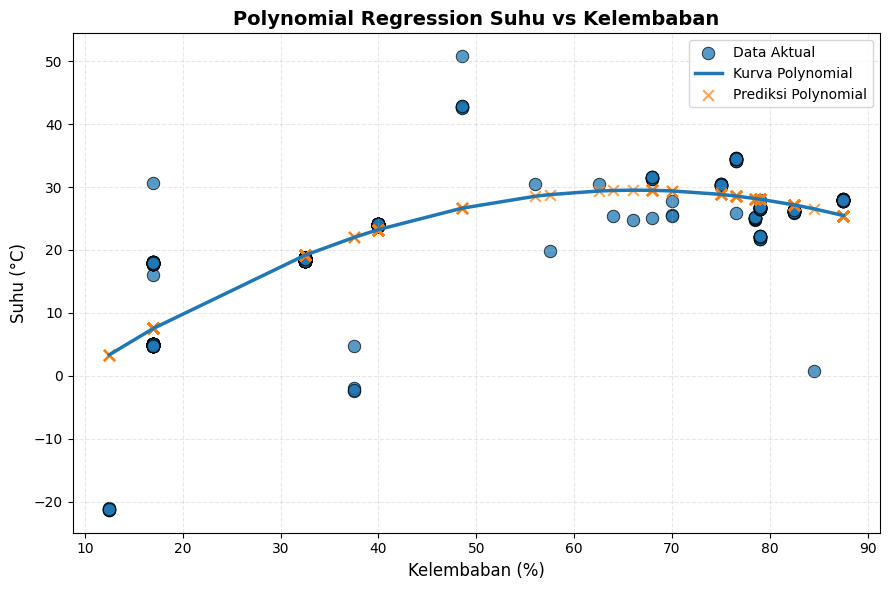

In [54]:
# Visualisasi Regresi Polynomial

plt.figure(figsize=(9, 6))

# Scatter data asli
plt.scatter(
      df["kelembaban"],
      df["suhu"],
      marker='o',
      s=80,
      alpha=0.75,
      edgecolors='black',
      linewidths=0.7,
      label='Data Aktual'
    )

# Urutkan untuk kurva halus
sorted_df = df.sort_values(by="kelembaban")

# Transform ke polynomial
X_sorted = sorted_df[["kelembaban"]]
X_sorted_poly = poly.transform(X_sorted)

# Prediksi polynomial (kurva)
y_poly_sorted = model_poly.predict(X_sorted_poly)
plt.plot(
      sorted_df["kelembaban"],
      y_poly_sorted,
      linestyle='-',
      linewidth=2.5,
      label='Kurva Polynomial'
    )

# Titik prediksi
plt.scatter(
        df["kelembaban"],
        df["Prediksi_Poly"],
        marker='x',
        s=60,
        alpha=0.7,
      label='Prediksi Polynomial'
    )
plt.title("Polynomial Regression Suhu vs Kelembaban", fontsize=14, fontweight='bold')
plt.xlabel("Kelembaban (%)", fontsize=12)
plt.ylabel("Suhu (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# Prediksi Suhu

input_baru = pd.DataFrame([[50]], columns=["kelembaban"])
prediksi = model.predict(input_baru)

print("Prediksi Suhu saat kelembaban 50%: ", prediksi[0])

Prediksi Suhu saat kelembaban 50%:  [21.63634412]
